# 1.7. Составные балки

### Beam.join()

`join(*beam*, *via='fixed'*)`

Этот метод соединяет две балки, создавая новую составную балочную систему. Передаваемый экземпляр класса балки присоединяется к правому концу вызывающего объекта. Этот метод может использоваться для формирования балок с разрывными значениями модуля упругости или момента инерции.

**Параметры**

**beam**: объект класса Beam

> Объект балки, который будет присоединен справа к вызывающему объекту.

**via**: Строка

> Указывает способ соединения двух объектов балок:
> - Для жестко (неподвижно) соединенных балок: via="fixed"
> - Для балок, соединенных шарниром вращения: via="hinge"

#### Пример

Имеется консольная балка длиной 4 метра. Для первых 2 метров ее момент инерции составляет `1.5 * I`, а для оставшейся части — `I`. К свободному концу сверху приложена сосредоточенная сила величиной 4 Н.

In [4]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
R1, R2 = symbols('R1, R2')
b1 = Beam(2, E, 1.5*I)
b2 = Beam(2, E, I)
b = b1.join(b2, "fixed")
b.apply_load(20, 4, -1)
b.apply_load(R1, 0, -1)
b.apply_load(R2, 0, -2)
b.bc_slope = [(0, 0)]
b.bc_deflection = [(0, 0)]
b.solve_for_reaction_loads(R1, R2)

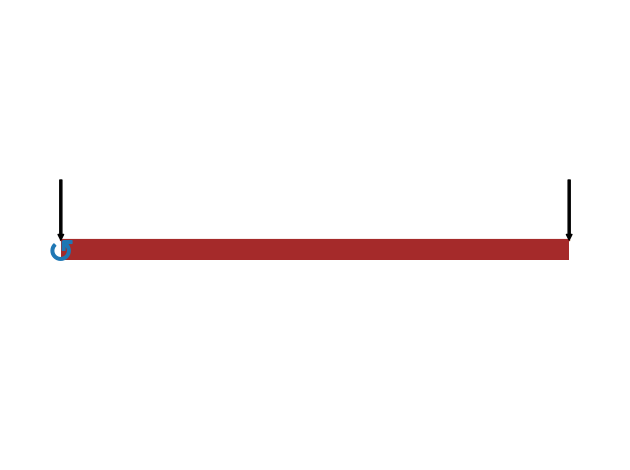

In [6]:
p = b.draw()
p.show()

In [2]:
b.load

80*SingularityFunction(x, 0, -2) - 20*SingularityFunction(x, 0, -1) + 20*SingularityFunction(x, 4, -1)

In [3]:
b.slope()

(-((-80*SingularityFunction(x, 0, 1) + 10*SingularityFunction(x, 0, 2) - 10*SingularityFunction(x, 4, 2))/I + 120/I)/E + 80.0/(E*I))*SingularityFunction(x, 2, 0) - 0.666666666666667*(-80*SingularityFunction(x, 0, 1) + 10*SingularityFunction(x, 0, 2) - 10*SingularityFunction(x, 4, 2))*SingularityFunction(x, 0, 0)/(E*I) + 0.666666666666667*(-80*SingularityFunction(x, 0, 1) + 10*SingularityFunction(x, 0, 2) - 10*SingularityFunction(x, 4, 2))*SingularityFunction(x, 2, 0)/(E*I)